# Wisp Bot — Rule-Based AI Chatbot

**DecodeLabs Industrial Training Kit · Project 1 · Batch 2026**

A sophisticated rule-based chatbot that simulates human conversation through pattern matching,
fuzzy string similarity, and context-aware response generation.

---

### Pipeline

| Step | Component | Description |
|:----:|:---------:|:------------|
| 1 | **Input Capture** | User text captured in a continuous interactive loop |
| 2 | **Preprocessing** | Lowercase normalization, punctuation filtering |
| 3 | **Fuzzy Matching** | `SequenceMatcher`-based similarity scoring against known patterns |
| 4 | **Intent Detection** | Highest-confidence intent selected from the knowledge base |
| 5 | **Response Generation** | Randomized response from the matched intent pool |
| 6 | **Context Memory** | Remembers user name and personalizes future replies |
| 7 | **Analytics** | Tracks intents, recognition rate, and conversation timeline |
| 8 | **Gradio App** | Interactive web-based chat interface for live demo |

## Dependencies

In [1]:
!pip install -q gradio

## Imports

In [2]:
import random
import difflib
import datetime
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130
matplotlib.rcParams["font.family"] = "sans-serif"

import gradio as gr
from IPython.display import display, Markdown

## Knowledge Base

The chatbot's intelligence comes from a structured dictionary mapping **intents** to patterns and responses.
Each intent contains a list of trigger patterns and a pool of randomized responses for natural-feeling variety.

In [9]:
KNOWLEDGE_BASE = {
    "greetings": {
        "patterns": [
            "hello", "hi", "hey", "good morning", "good evening",
            "good afternoon", "howdy", "greetings", "sup", "whats up"
        ],
        "responses": [
            "Hey there! How can I help you today?",
            "Hello! Great to see you! What's on your mind?",
            "Hi! I'm ready to chat. Ask me anything!",
            "Hey! Welcome back! What can I do for you?"
        ]
    },
    "farewell": {
        "patterns": [
            "bye", "goodbye", "exit", "quit", "see you",
            "later", "farewell", "take care", "peace out"
        ],
        "responses": [
            "Goodbye! Have an amazing day!",
            "See you later! It was great chatting!",
            "Take care! Come back anytime!",
            "Bye bye! Stay awesome!"
        ]
    },
    "how_are_you": {
        "patterns": [
            "how are you", "how do you do", "hows it going",
            "how are things", "you good", "whats up with you"
        ],
        "responses": [
            "I'm doing fantastic, thanks for asking! How about you?",
            "Running at full capacity! All systems go!",
            "I'm great! Every conversation makes me better. How are you?",
            "Living my best digital life! What about you?"
        ]
    },
    "name": {
        "patterns": [
            "what is your name", "who are you",
            "what should i call you", "your name", "tell me your name"
        ],
        "responses": [
            "I'm Wisp Bot, your AI assistant from DecodeLabs!",
            "Call me Wisp Bot — I'm here to help and chat!",
            "I go by Wisp Bot. Nice to meet you!"
        ]
    },
    "help": {
        "patterns": [
            "help", "what can you do", "capabilities",
            "features", "commands", "options"
        ],
        "responses": [
            "I can help with:\n- General conversation & small talk\n- AI and ML concepts\n- Python programming tips\n- Jokes and fun facts\n- Emotional support\n- Time queries\nJust ask away!"
        ]
    },
    "jokes": {
        "patterns": [
            "tell me a joke", "joke", "make me laugh", "funny", "humor"
        ],
        "responses": [
            "Why do programmers prefer dark mode? Because light attracts bugs!",
            "Why did the neural network break up? Too many layers of issues!",
            "What's a computer's favorite snack? Microchips!",
            "Why was the AI bad at soccer? It kept trying to find the goal function!",
            "How do trees access the internet? They log in!"
        ]
    },
    "ai_concepts": {
        "patterns": [
            "what is ai", "artificial intelligence",
            "explain ai", "define ai", "what is artificial intelligence"
        ],
        "responses": [
            "Artificial Intelligence (AI) is the simulation of human intelligence by machines. It includes learning from data, reasoning, and self-correction. Think of it as teaching computers to think!",
            "AI is a field of computer science focused on creating systems that can perform tasks that typically require human intelligence — like understanding language, recognizing images, and making decisions!"
        ]
    },
    "ml_concepts": {
        "patterns": [
            "what is machine learning", "explain ml",
            "define machine learning", "what is ml"
        ],
        "responses": [
            "Machine Learning is a subset of AI where systems learn from data without being explicitly programmed. It discovers patterns and makes decisions with minimal human intervention!",
            "ML is the science of getting computers to act without being explicitly programmed. Instead of writing rules, you feed data and let the algorithm learn the patterns!"
        ]
    },
    "python_info": {
        "patterns": [
            "what is python", "tell me about python",
            "python programming", "why python"
        ],
        "responses": [
            "Python is a versatile, high-level programming language loved for its clean syntax. It's the #1 language for AI, Data Science, and ML thanks to libraries like TensorFlow, PyTorch, and scikit-learn!"
        ]
    },
    "dl_concepts": {
        "patterns": [
            "what is deep learning", "explain deep learning",
            "define deep learning", "what is dl", "neural networks"
        ],
        "responses": [
            "Deep Learning is a subset of ML that uses neural networks with many layers. It excels at image recognition, NLP, and speech — powering things like self-driving cars and virtual assistants!",
            "Deep Learning uses artificial neural networks inspired by the human brain. Multiple layers of neurons process data to learn increasingly complex features!"
        ]
    },
    "happy": {
        "patterns": [
            "i am happy", "im happy", "feeling good",
            "feeling great", "i feel amazing", "wonderful"
        ],
        "responses": [
            "That's wonderful to hear! Keep spreading those good vibes!",
            "Amazing! Happiness is contagious — you just made my circuits light up!",
            "Love to hear it! What's making your day great?"
        ]
    },
    "sad": {
        "patterns": [
            "i am sad", "im sad", "feeling down",
            "not good", "feeling bad", "depressed", "unhappy"
        ],
        "responses": [
            "I'm sorry to hear that. Remember, tough times don't last, but tough people do!",
            "It's okay to feel down sometimes. Want to hear a joke to cheer you up?",
            "Sending you virtual hugs! Things will get better, I promise."
        ]
    },
    "bored": {
        "patterns": [
            "i am bored", "im bored", "nothing to do", "boring"
        ],
        "responses": [
            "Bored? Let's fix that! Want to hear a fun AI fact or a joke?",
            "How about learning something new? Ask me about AI or Machine Learning!",
            "Boredom is just your brain asking for a challenge. Let me quiz you on something!"
        ]
    },
    "thanks": {
        "patterns": [
            "thank you", "thanks", "appreciate it", "thx", "ty", "grateful"
        ],
        "responses": [
            "You're welcome! Happy to help!",
            "Anytime! That's what I'm here for!",
            "No problem at all! Feel free to ask anything else!"
        ]
    },
    "creator": {
        "patterns": [
            "who made you", "who created you", "who built you",
            "your creator", "who is your developer"
        ],
        "responses": [
            "I was crafted at DecodeLabs as part of the AI Industrial Training program! Built with Python and lots of logic!",
            "The brilliant minds at DecodeLabs brought me to life! I'm a product of their AI training kit."
        ]
    },
    "time": {
        "patterns": [
            "what time is it", "current time",
            "tell me the time", "time please"
        ],
        "responses": ["__TIME__"]
    },
    "fun_facts": {
        "patterns": [
            "fun fact", "tell me a fact", "interesting fact",
            "random fact", "did you know"
        ],
        "responses": [
            "Did you know? The first AI program was written in 1951 by Christopher Strachey — it played checkers!",
            "Fun fact: GPT-3 has 175 billion parameters. That's more than the number of stars visible to the naked eye!",
            "Here's a cool one: The term 'Artificial Intelligence' was coined in 1956 at the Dartmouth Conference!",
            "Did you know? Netflix's recommendation system saves them about $1 billion per year!",
            "Fun fact: It would take about 1,000 human years to watch all the video uploaded to YouTube in a single day!"
        ]
    }
}

## Text Preprocessing

Normalizes user input by converting to lowercase and stripping non-essential characters
to improve pattern matching accuracy.

In [4]:
def preprocess(text):
    text = text.lower().strip()
    text = "".join(c for c in text if c.isalnum() or c.isspace() or c in "'-")
    return text

## Wisp Bot Engine

The core chatbot class combining fuzzy string matching (`difflib.SequenceMatcher`),
exact substring detection, user name memory, and conversation history tracking.

In [12]:
class WispBot:

    def __init__(self):
        self.user_name = None
        self.history = []
        self.intent_counts = Counter()
        self.session_start = datetime.datetime.now()

    def find_intent(self, user_input):
        processed = preprocess(user_input)
        best_match = None
        best_score = 0.0

        for intent, data in KNOWLEDGE_BASE.items():
            for pattern in data["patterns"]:
                if pattern in processed:
                    return intent, 1.0
                score = difflib.SequenceMatcher(None, processed, pattern).ratio()
                if score > best_score:
                    best_score = score
                    best_match = intent

        if best_score >= 0.6:
            return best_match, best_score
        return None, 0.0

    def check_name_input(self, user_input):
        processed = preprocess(user_input)
        triggers = ["my name is", "i am called", "call me", "im "]
        for trigger in triggers:
            if trigger in processed:
                name = processed.split(trigger)[-1].strip().title()
                if name:
                    self.user_name = name
                    return f"Nice to meet you, {self.user_name}! I'll remember your name."
        return None

    def respond(self, user_input):
        if not user_input.strip():
            return "I didn't catch that. Could you say something?"

        name_response = self.check_name_input(user_input)
        if name_response:
            self.history.append({"input": user_input, "intent": "name_intro", "response": name_response})
            return name_response

        intent, confidence = self.find_intent(user_input)

        if intent and intent in KNOWLEDGE_BASE:
            self.intent_counts[intent] += 1
            responses = KNOWLEDGE_BASE[intent]["responses"]

            if intent == "time":
                response = f"The current time is {datetime.datetime.now().strftime('%H:%M:%S')}"
            else:
                response = random.choice(responses)

            if self.user_name and random.random() > 0.7:
                response = f"{self.user_name}, " + response[0].lower() + response[1:]

            self.history.append({"input": user_input, "intent": intent, "response": response})
            return response

        fallback_responses = [
            "Hmm, I'm not sure about that. Could you rephrase?",
            "Interesting! I don't have info on that yet, but I'm always learning!",
            "I didn't quite get that. Try asking about AI, jokes, or just say hi!",
            "That's beyond my current knowledge. Want to try something else?"
        ]
        response = random.choice(fallback_responses)
        self.history.append({"input": user_input, "intent": "unknown", "response": response})
        self.intent_counts["unknown"] += 1
        return response

## Conversation Demo

A simulated conversation showcasing the chatbot's capabilities across multiple intent categories.

In [13]:
bot = WispBot()

demo_inputs = [
    "Hello!",
    "My name is Aarav",
    "What can you do?",
    "Tell me about AI",
    "What is deep learning?",
    "Tell me a joke",
    "I'm feeling a bit bored",
    "Give me a fun fact",
    "What time is it?",
    "helo there",
    "Thanks!",
    "Bye!"
]

for user_msg in demo_inputs:
    response = bot.respond(user_msg)
    display(Markdown(f"**You:** {user_msg}"))
    display(Markdown(f"**Wisp Bot:** {response}"))
    display(Markdown("---"))

**You:** Hello!

**Wisp Bot:** Hey there! How can I help you today?

---

**You:** My name is Aarav

**Wisp Bot:** Nice to meet you, Aarav! I'll remember your name.

...

**Wisp Bot:** Aarav, you're welcome! Happy to help!

---

**You:** Bye!

**Wisp Bot:** Aarav, goodbye! Have an amazing day!

---

## Conversation Analytics

Visualizing the chatbot's performance: which intents were triggered and the conversation timeline.

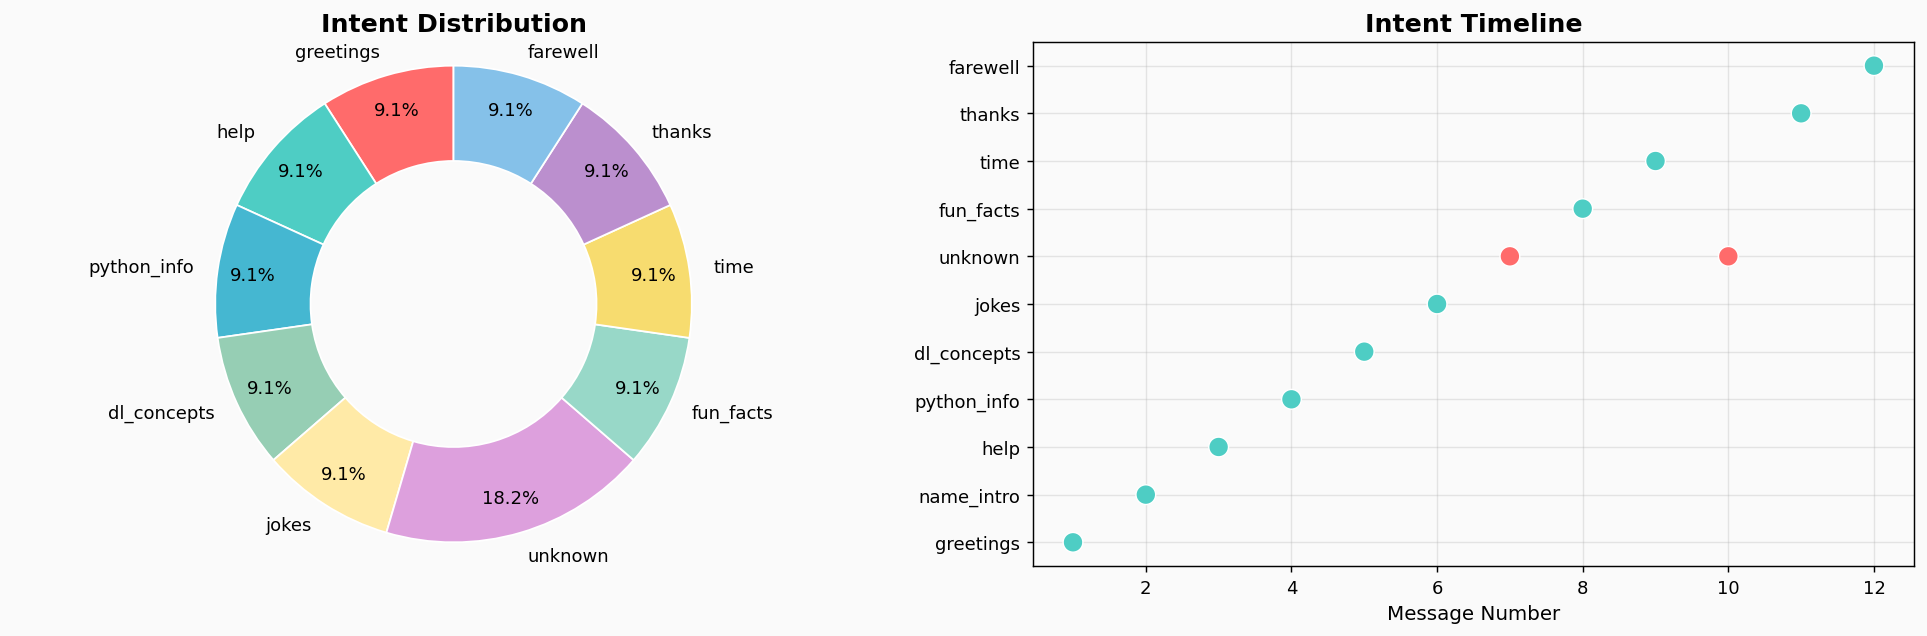

### Session Summary

- **Total messages:** 12

- **Unique intents triggered:** 10

- **Unknown queries:** 2

- **Recognition rate:** 83.3%

In [15]:
PALETTE = [
    "#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7",
    "#DDA0DD", "#98D8C8", "#F7DC6F", "#BB8FCE", "#85C1E9",
    "#F0B27A", "#AED6F1", "#A3E4D7", "#FAD7A0", "#D2B4DE"
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor("#FAFAFA")

# Prepare data for the pie chart, filtering out intents with zero count
filtered_intents = [intent for intent, count in bot.intent_counts.items() if count > 0]
filtered_counts = [count for intent, count in bot.intent_counts.items() if count > 0]
pie_colors = PALETTE[:len(filtered_intents)]

# Create the donut chart for Intent Distribution
axes[0].pie(filtered_counts, labels=filtered_intents, autopct='%1.1f%%', startangle=90, colors=pie_colors,
            pctdistance=0.85, wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title("Intent Distribution", fontweight="bold", fontsize=14)
axes[0].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
axes[0].set_facecolor("#FAFAFA")

timeline_intents = [h["intent"] for h in bot.history]
msg_numbers = list(range(1, len(timeline_intents) + 1))
scatter_colors = ["#4ECDC4" if i != "unknown" else "#FF6B6B" for i in timeline_intents]

axes[1].scatter(msg_numbers, timeline_intents, c=scatter_colors, s=120, edgecolors="white", linewidth=0.8, zorder=5)
axes[1].set_xlabel("Message Number", fontsize=11)
axes[1].set_title("Intent Timeline", fontweight="bold", fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor("#FAFAFA")

plt.tight_layout()
plt.show()

total = len(bot.history)
unknown = bot.intent_counts.get("unknown", 0)
rate = (1 - unknown / total) * 100 if total > 0 else 0

display(Markdown("### Session Summary"))
display(Markdown(f"- **Total messages:** {total}"))
display(Markdown(f"- **Unique intents triggered:** {len(bot.intent_counts)}"))
display(Markdown(f"- **Unknown queries:** {unknown}"))
display(Markdown(f"- **Recognition rate:** {rate:.1f}%"))

## Interactive Gradio App

Launch a live chat interface powered by Gradio. The app runs inline in the notebook
and also generates a public shareable link valid for 72 hours.

In [14]:
bot_gradio = WispBot()


def chat_fn(message, history):
    return bot_gradio.respond(message)


demo = gr.ChatInterface(
    fn=chat_fn,
    title="Wisp Bot — Rule-Based AI Chatbot",
    description=(
        "Wisp Bot is a rule-based chatbot with fuzzy matching and pattern recognition. "
        "Try greeting me, asking about AI, or telling me your name!"
    ),
    theme=gr.themes.Soft(),
    examples=[
        "Hello!",
        "Tell me a joke",
        "What is AI?",
        "My name is Alex",
        "I'm feeling bored",
        "Give me a fun fact",
    ],
)

demo.launch()

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://02f728ab6d00216d7b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
